# Insurance Claims - Complete EDA & Preprocessing

This notebook takes the raw `insurance_claims_10k.csv` all the way to model-ready matrices.

| # | Section | What happens |
|---|---------|--------------|
| 0 | Setup | imports and settings you can change |
| 1 | Raw data profile | how messy the file really is |
| 2 | Cleaning | placeholders, units, typos, dates, impossible values, duplicates, target |
| 3 | EDA | target balance, missing values, distributions, outliers, correlation, category fraud rates, feature ranking |
| 4 | Feature engineering | new row-wise features (no leakage) |
| 5 | Preprocessing | stratified split, then **fit on train only**: pruning, imputation, power transform, scaling, encoding, class imbalance |
| 6 | Save & verify | model-ready files + fitted preprocessor + round-trip check |

**How to use:** put `insurance_claims_10k.csv` next to this notebook, then **Run All**. Everything is written to the `output/` folder.

**Requirements:** `pandas>=2`, `numpy`, `scipy`, `scikit-learn>=1.2`, `matplotlib`, `joblib` (optional: `imbalanced-learn` for SMOTE).

## 0. Setup & configuration

In [1]:
import difflib
import json
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, PowerTransformer,
                                   StandardScaler)
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False})

# ----------------------------- settings you can change -----------------------------
INPUT_PATH = "insurance_claims_10k.csv"   # raw data file
OUTDIR = Path("output")                   # everything is saved here
SEED = 42                                 # reproducibility
TEST_SIZE = 0.2                           # share of rows held out for testing
CORR_THRESHOLD = 0.9                      # drop one of any numeric pair with |r| >= this
BALANCE_METHOD = "oversample"             # "none" | "oversample" | "smote" (needs imbalanced-learn)
# -----------------------------------------------------------------------------------

TARGET = "fraud_reported"
C0, C1 = "#3182ce", "#e53e3e"             # colours: no fraud / fraud
(OUTDIR / "processed").mkdir(parents=True, exist_ok=True)

## 1. Load the raw data & profile its quality

Everything is loaded as **text** (`dtype=str`) so pandas does not silently turn messy values into NaN or wrong numbers.

In [2]:
raw = pd.read_csv(INPUT_PATH, dtype=str)
print(f"Raw file: {raw.shape[0]:,} rows x {raw.shape[1]} columns | exact duplicate rows: {raw.duplicated().sum()}")
display(raw.head())

Raw file: 10,000 rows x 40 columns | exact duplicate rows: 220


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,278,47,581816,"Feb 25, 1990",oh,250/500,1000,1242.21,3000000,463-337,FEMALE,Associate,prof-specialty,chess,husband,0,0,2015-01-22,Single Vehicle Collision,Front Collision,Major Damage,Ambulance,WV,Northbend,3977 Apache Drive,NaN,1,YES,2,3,NO,68210,NaN,6200,55810,Toyota,Camry,1995,Y,NaN
1,464,57,978555,1992-07-30,IN,100/300,1000,1583.55,0,433924,FEMALE,NaN,sales,hiking,not-in-family,70300,-28500,2015-01-28,Multi-vehicle Collision,Rear Collision,Major Damage,Fire,VA,Hillsdale,5277 Apache St,16,2,YES,1,0,NO,66180,6020,12030,48130,Saab,93,2014,N,NaN
2,170,32,618236,20030401,OH,500/1000,2000,1221.12,0,441485,FEMALE,High School,other-service,dancing,not-in-family,0,0,10.01.2015,Single Vehicle Collision,Front Collision,Total Loss,Fire,VA,Riverwood,5760 4th Ave,10,1,YES,1,0,?,61990,6200,6200,49590,Dodge,RAM,1997,N,NaN
3,157,37,702580,1992-09-09,INDIANA,500/1000,NaN,912.65,0,620800,Female,Masters,exec-managerial,movies,own-child,0,0,2015-02-24,Multivehicle Collision,Side Collision,Minor Damage,Police,SC,Northbrook,8905 Solo Drive,17,3,NO,1,2,YES,69550,"$6,960",13910,48680,saab,95,2005,N,NaN
4,238,36,851599,2013-04-05,IN,500/1000,2000,1506.72,6000000,463938,FEMALE,High School,other-service,hiking,Not-In-Family,0,-49800,"February 15, 2015",Multi-vehicle Collision,Rear Collision,Major Damage,Ambulance,NY,Hillsdale,7114 Solo Drive,3,3,YES,2,1,YES,46360,9270,4640,32450.0,Dodge,RAM,2005,Y,NaN


In [3]:
PLACEHOLDER_SET = {"", "?", "-", "--", "---", "unknown", "n/a", "na", "nan", "null", "none "}
profile = pd.DataFrame({
    "missing": raw.isna().sum(),
    "missing_%": (raw.isna().mean() * 100).round(1),
    "placeholders (?, -, unknown...)": raw.apply(lambda s: s.str.strip().str.lower().isin(PLACEHOLDER_SET).sum()),
    "distinct_raw_values": raw.nunique(),
})
display(profile)

,missing,missing_%,"placeholders (?, -, unknown...)",distinct_raw_values
months_as_customer,129,1.3,38,788
age,227,2.3,42,153
policy_number,13,0.1,3,9651
policy_bind_date,147,1.5,32,7620
policy_state,53,0.5,22,26
policy_csl,59,0.6,23,36
policy_deductable,63,0.6,13,14
policy_annual_premium,244,2.4,41,8985
umbrella_limit,289,2.9,46,42
insured_zip,124,1.2,21,8892


The "distinct raw values" column shows the problem: `insured_sex` should have 2 values, `insured_education_level` 7, and so on.
Here is what hides inside a few columns:

In [4]:
print("insured_sex (raw) ->", raw["insured_sex"].value_counts().head(12).to_dict())
print("\nage, non-numeric examples ->", raw.loc[pd.to_numeric(raw["age"], errors="coerce").isna() & raw["age"].notna(), "age"].head(8).tolist())
print("incident_hour, non-numeric examples ->", raw.loc[pd.to_numeric(raw["incident_hour_of_the_day"], errors="coerce").isna() & raw["incident_hour_of_the_day"].notna(), "incident_hour_of_the_day"].head(8).tolist())
print("total_claim_amount, non-numeric examples ->", raw.loc[pd.to_numeric(raw["total_claim_amount"], errors="coerce").isna() & raw["total_claim_amount"].notna(), "total_claim_amount"].head(8).tolist())
print("policy_bind_date examples ->", raw["policy_bind_date"].dropna().sample(8, random_state=1).tolist())
print("fraud_reported (raw) ->", raw["fraud_reported"].value_counts().to_dict())

insured_sex (raw) -> {'FEMALE': 4090, 'MALE': 3508, 'female': 243, 'FEMALE ': 182, 'Female': 178, ' Female': 171, 'MALE ': 169, 'Male': 154, 'f': 150, 'Femal': 149, 'male': 147, 'F': 143}

age, non-numeric examples -> ['-', '45 yrs', '31y', '35y', '22 yrs', '37 yrs', '34 yrs', '53 yrs']
incident_hour, non-numeric examples -> ['12 PM', '22:00', '13:00', '17:00', '03:00', '19:00', '16:00', '10:00']
total_claim_amount, non-numeric examples -> ['$8,070', '48320 USD', '$67,290', '$73,220', '$29,970', '$90,520', '45,080', '$91,010']
policy_bind_date examples -> ['2009-09-16', '24/12/1999', '05-01-2006', 'Oct 21, 1995', '1990-07-02', '2003-02-25', '2010-06-20', '2004/03/21']
fraud_reported (raw) -> {'N': 6818, 'Y': 2277, 'No': 107, 'Non-Fraud': 104, 'no': 93, 'false': 93, '0': 91, 'FALSE': 79, 'n': 66, 'y': 34, 'Fraud': 32, 'Yes': 32, '1': 29, 'yes': 29, 'true': 24, 'TRUE': 22}


## 2. Cleaning

### 2.1 Cleaning rules (edit here) and helper functions
`NUMERIC_RANGES` holds the valid (min, max) for every numeric column - anything outside is treated as invalid and set to NaN.
These ranges come from the data's distribution and domain sense; adjust them if you disagree.

In [5]:
PLACEHOLDERS = {"", "?", "-", "--", "---", "unknown", "n/a", "na", "nan", "null", "none "}

DROP_COLS = ["_c39", "policy_number", "insured_zip", "incident_location"]

# (min, max) inclusive. Values outside are treated as invalid -> NaN.
NUMERIC_RANGES = {
    "age": (16, 100),
    "months_as_customer": (0, 600),
    "policy_deductable": (0, 5000),
    "policy_annual_premium": (1, 3000),
    "umbrella_limit": (0, 10_000_000),
    "capital-gains": (0, 120_000),
    "capital-loss": (-120_000, 0),
    "incident_hour_of_the_day": (0, 23),
    "number_of_vehicles_involved": (1, 4),
    "bodily_injuries": (0, 2),
    "witnesses": (0, 3),
    "total_claim_amount": (0, 120_000),
    "injury_claim": (0, 50_000),
    "property_claim": (0, 50_000),
    "vehicle_claim": (0, 120_000),
    "auto_year": (1980, 2015),
}
INT_COLS = ["age", "months_as_customer", "policy_deductable", "umbrella_limit",
            "incident_hour_of_the_day", "number_of_vehicles_involved",
            "bodily_injuries", "witnesses", "auto_year"]

VALID_CSL = {"100/300", "250/500", "500/1000"}
# Order matters: for ambiguous strings like 05-01-2006 day-first is tried first, but a
# result outside the valid date range is rejected so the next format gets a chance
# (e.g. 01-15-2015 fails d-m-Y because there is no month 15 and falls to m-d-Y).
DATE_FORMATS = ["%Y-%m-%d", "%Y/%m/%d", "%Y%m%d", "%d.%m.%Y", "%d-%m-%Y", "%m-%d-%Y",
                "%d/%m/%Y", "%m/%d/%Y", "%d-%b-%Y", "%b %d, %Y", "%B %d, %Y"]
MIN_BIND_DATE = pd.Timestamp("1985-01-01")
BIND_DATE_PLACEHOLDER = pd.Timestamp("1990-01-01")  # suspicious spike (29 rows)
INCIDENT_DATE_RANGE = (pd.Timestamp("2015-01-01"), pd.Timestamp("2015-03-31"))

WORD_NUMBERS = {"zero": 0, "one": 1, "two": 2, "three": 3, "four": 4, "five": 5}

TARGET = "fraud_reported"
REFERENCE_YEAR = 2015                       # incident year, used for vehicle_age
CAT_AS_NUMERIC = ["incident_month", "incident_dayofweek"]   # numbers that are really categories
ORDINAL_ORDER = {                           # ordered categoricals (low -> high)
    "insured_education_level": ["High School", "Associate", "College", "Masters", "JD", "MD", "PhD"],
    "incident_severity": ["Trivial Damage", "Minor Damage", "Major Damage", "Total Loss"],
    "policy_csl": ["100/300", "250/500", "500/1000"],
}

**Number parsing** - understands `$1,000`, `(10,000)` (negative), `7.0K`, `3M`, `30650 USD`, `37 yrs`, `12 months`, `14:00`, `3 PM`.

In [6]:
_NUM_RE = re.compile(
    r"(-?)\s*\$?\s*(-?)(\d+(?:\.\d+)?)\s*([km]?)\s*(usd|yrs?|years?|y|months?|mos?)?")

def parse_number(v):
    """
    Robust number parser. Handles: '$1,000', '1,000', '500.0', '-$0', '(10,000)'
    (negative), '7.0K' / '3M' (thousand / million), '30650 USD', '37 yrs', '37y',
    '12 months'. Anything else -> NaN.
    """
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float, np.number)):
        return float(v)
    s = str(v).strip().lower().replace(",", "")
    neg = s.startswith("(") and s.endswith(")")
    s = s.strip("()").strip()
    m = _NUM_RE.fullmatch(s)
    if not m:
        return np.nan
    sign = -1 if (m.group(1) == "-" or m.group(2) == "-" or neg) else 1
    return sign * float(m.group(3)) * {"": 1, "k": 1e3, "m": 1e6}[m.group(4)]

def parse_hour(v):
    """'14:00' -> 14, '3 PM' -> 15, '12 AM' -> 0, otherwise a plain number."""
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    m = re.fullmatch(r"(\d{1,2}):(\d{2})(?::\d{2})?", s)
    if m:
        return float(m.group(1))
    m = re.fullmatch(r"(\d{1,2})\s*(am|pm)", s)
    if m:
        return float(int(m.group(1)) % 12 + (12 if m.group(2) == "pm" else 0))
    return parse_number(v)

def to_num(s, parser=parse_number):
    """Apply a parser to the unique values of a column (fast) -> float Series."""
    lookup = {u: parser(u) for u in s.dropna().unique()}
    return s.map(lookup).astype(float)

**Label standardisation** - fuzzy matching fixes typos (`FEMAL`, `Colllege`, `Suburu`) and maps aliases (`VW`, `S.C.`, `HS`).

In [7]:
def norm_key(x):
    """Lowercase and strip everything except letters/digits: 'W. Virginia ' -> 'wvirginia'."""
    if pd.isna(x):
        return np.nan
    return re.sub(r"[^a-z0-9]", "", str(x).lower())

def canon(series, mapping, cutoff=0.75):
    """
    Map messy labels to canonical ones.
      mapping: {normalized_key: Canonical Label} (include aliases as extra keys)
    Exact match on normalized key first, then fuzzy match (typos) for keys > 3 chars.
    Anything unmatched -> NaN.
    """
    keys = list(mapping.keys())
    cache = {}

    def _map(v):
        k = norm_key(v)
        if pd.isna(k):
            return np.nan
        if k in cache:
            return cache[k]
        if k in mapping:
            out = mapping[k]
        elif len(k) > 3:
            m = difflib.get_close_matches(k, [x for x in keys if len(x) > 3], n=1, cutoff=cutoff)
            out = mapping[m[0]] if m else np.nan
        else:
            out = np.nan
        cache[k] = out
        return out

    return series.map(_map)

def canon_from_list(series, labels, aliases=None, cutoff=0.75):
    mapping = {norm_key(l): l for l in labels}
    for a, l in (aliases or {}).items():
        mapping[norm_key(a)] = l
    return canon(series, mapping, cutoff)

def canon_auto(series, min_count=50, cutoff=0.8):
    """
    For free-ish text columns: labels that appear >= min_count times (after
    normalisation) are treated as canonical; rarer spellings are fuzzy-matched
    onto them. Label shown = most common raw spelling of that key.
    """
    keys = series.map(norm_key)
    counts = keys.value_counts()
    frequent = counts[counts >= min_count].index.tolist()
    labels = {}
    for k in frequent:
        labels[k] = series[keys == k].value_counts().index[0]
    return canon(series, labels, cutoff)

def yes_no(series):
    yes = {"yes", "y", "true", "1", "t"}
    no = {"no", "n", "false", "0", "f"}

    def _m(v):
        k = norm_key(v)
        if pd.isna(k):
            return np.nan
        return "YES" if k in yes else "NO" if k in no else np.nan

    return series.map(_m)

**Date parsing** - tries 11 formats; a result outside the valid date range is rejected so ambiguous strings (`01-15-2015`) fall through to the right format.

In [8]:
def parse_dates(series, valid_range=(pd.Timestamp("1900-01-01"), pd.Timestamp("2100-01-01"))):
    """Try each known format in turn; results outside valid_range are rejected."""
    s = series.astype("string").str.strip()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    for fmt in DATE_FORMATS:
        todo = out.isna() & s.notna()
        if not todo.any():
            break
        parsed = pd.to_datetime(s[todo], format=fmt, errors="coerce")
        # drop absurd years first (keeps the cast to ns safe), then align dtype
        parsed = parsed.where(parsed.dt.year.between(1900, 2100))
        parsed = parsed.where(parsed.between(*valid_range)).astype("datetime64[ns]")
        out.loc[todo] = parsed
    return out

def count_new_nan(before, after):
    return int((after.isna() & before.notna()).sum())

### 2.2 Drop useless columns, blank out placeholders, remove exact duplicates
* `_c39` is 100% empty, `policy_number`/`insured_zip`/`incident_location` are IDs or near-unique text with no predictive value.
* `?`, `-`, `--`, `Unknown`, blanks all become real missing values.

In [9]:
df = raw.copy()
present = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=present)
print("Dropped columns:", present)

for c in df.columns:
    df[c] = df[c].str.strip()
    df.loc[df[c].str.lower().isin(PLACEHOLDERS), c] = np.nan

n = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {n - len(df)} exact duplicate rows -> {len(df):,} rows")

Dropped columns: ['_c39', 'policy_number', 'insured_zip', 'incident_location']
Removed 220 exact duplicate rows -> 9,780 rows


### 2.3 Target column
`fraud_reported` has 16 spellings (`Y`, `Yes`, `true`, `1`, `Fraud`, ...). Map them to 1/0 and drop rows with no usable label.

In [10]:
fraud_yes = {"y", "yes", "true", "1", "fraud", "t"}
fraud_no = {"n", "no", "false", "0", "nonfraud", "f"}
df[TARGET] = df[TARGET].map(
    lambda v: np.nan if pd.isna(v) else 1 if norm_key(v) in fraud_yes
    else 0 if norm_key(v) in fraud_no else np.nan)
n = len(df)
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
df[TARGET] = df[TARGET].astype(int)
print(f"Dropped {n - len(df)} rows with missing/unrecognised target -> {len(df):,} rows")
print(df[TARGET].value_counts().to_dict())

Dropped 69 rows with missing/unrecognised target -> 9,711 rows
{0: 7288, 1: 2423}


### 2.4 Numeric columns
Parse every numeric column with the robust parser, then set values outside `NUMERIC_RANGES` to NaN
(e.g. age 999, hour 99, year 2099, negative premiums, `9999999` capital-gains sentinels).

In [11]:
# number words -> digits first ("One", "Three")
df["number_of_vehicles_involved"] = df["number_of_vehicles_involved"].map(
    lambda v: WORD_NUMBERS.get(str(v).lower(), v) if pd.notna(v) else v)

rows = []
for col, (lo, hi) in NUMERIC_RANGES.items():
    raw_col = df[col]
    x = to_num(raw_col, parse_hour if col == "incident_hour_of_the_day" else parse_number)
    unparseable = int((x.isna() & raw_col.notna()).sum())
    invalid = int(((x < lo) | (x > hi)).sum())
    df[col] = x.where((x >= lo) & (x <= hi))
    rows.append({"column": col, "valid_min": lo, "valid_max": hi, "unparseable": unparseable,
                 "out_of_range -> NaN": invalid, "missing_after": int(df[col].isna().sum())})
display(pd.DataFrame(rows))

# tenure (in months) cannot be longer than the customer's whole life
bad = df["months_as_customer"] > df["age"] * 12
df.loc[bad, "months_as_customer"] = np.nan
print(f"months_as_customer > age*12 set to NaN: {int(bad.sum())}")

months_as_customer > age*12 set to NaN: 37


,column,valid_min,valid_max,unparseable,out_of_range -> NaN,missing_after
0,age,16,100,0,50,317
1,months_as_customer,0,600,0,79,242
2,policy_deductable,0,5000,0,0,74
3,policy_annual_premium,1,3000,0,179,453
4,umbrella_limit,0,10000000,0,34,359
5,capital-gains,0,120000,0,35,474
6,capital-loss,-120000,0,0,76,544
7,incident_hour_of_the_day,0,23,0,40,221
8,number_of_vehicles_involved,1,4,0,24,133
9,bodily_injuries,0,2,0,24,232


### 2.5 Claim amounts: make the total consistent with its parts
`total_claim_amount` should equal injury + property + vehicle. We (1) recover one missing part when the total and the other two are known,
(2) flag inconsistent rows in `claim_total_mismatch`, and (3) recompute the total from the parts when the result is in the valid range.

In [12]:
parts = ["injury_claim", "property_claim", "vehicle_claim"]
for p in parts:
    others = [q for q in parts if q != p]
    m = df[p].isna() & df["total_claim_amount"].notna() & df[others].notna().all(axis=1)
    derived = df["total_claim_amount"] - df[others].sum(axis=1)
    ok = m & (derived >= 0)
    df.loc[ok, p] = derived[ok]

all_parts = df[parts].notna().all(axis=1)
mismatch = all_parts & ((df["total_claim_amount"] - df[parts].sum(axis=1)).abs() > 1)
df["claim_total_mismatch"] = (mismatch | (all_parts & df["total_claim_amount"].isna())).astype(int)

parts_sum = df[parts].sum(axis=1)
use_sum = all_parts & (parts_sum <= NUMERIC_RANGES["total_claim_amount"][1])
df.loc[use_sum, "total_claim_amount"] = parts_sum[use_sum]
print(f"Inconsistent rows flagged (claim_total_mismatch = 1): {int(df['claim_total_mismatch'].sum())}")

Inconsistent rows flagged (claim_total_mismatch = 1): 352


### 2.6 Dates -> usable features
Both date columns use many formats. After parsing we keep only plausible dates
(incident Jan-Mar 2015; bind date from 1985, before the incident, and not the suspicious `1990-01-01` placeholder),
then replace the raw dates with `policy_tenure_days`, `incident_month` and `incident_dayofweek`.

In [13]:
bind_raw, inc_raw = df["policy_bind_date"], df["incident_date"]
bind = parse_dates(bind_raw, (MIN_BIND_DATE, INCIDENT_DATE_RANGE[1]))
inc = parse_dates(inc_raw, INCIDENT_DATE_RANGE)
inc = inc.where(inc.between(*INCIDENT_DATE_RANGE))
bind = bind.where((bind != BIND_DATE_PLACEHOLDER) & ~(bind > inc))   # bind date must precede incident

print(f"policy_bind_date invalid/unparseable -> NaT: {count_new_nan(bind_raw, bind)}")
print(f"incident_date    invalid/unparseable -> NaT: {count_new_nan(inc_raw, inc)}")

df["policy_tenure_days"] = (inc - bind).dt.days
df["incident_month"] = inc.dt.month
df["incident_dayofweek"] = inc.dt.dayofweek
df = df.drop(columns=["policy_bind_date", "incident_date"])
display(df[["policy_tenure_days", "incident_month", "incident_dayofweek"]].describe().T)

policy_bind_date invalid/unparseable -> NaT: 150
incident_date    invalid/unparseable -> NaT: 27


,count,mean,std,min,25%,50%,75%,max
policy_tenure_days,9319.0,4736.103552,2655.186799,1.0,2530.0,4704.0,7036.5,9176.0
incident_month,9643.0,1.499222,0.534512,1.0,1.0,1.0,2.0,3.0
incident_dayofweek,9643.0,3.098310,1.998516,0.0,1.0,3.0,5.0,6.0


### 2.7 Categorical columns
Map every spelling variant to one canonical label:
states -> 2-letter codes, `policy_csl` -> `100/300` style, sex / education / incident type / severity / make from fixed lists (with fuzzy typo matching),
and frequency-based matching for occupation, hobbies, relationship, city and model.
`?` in `property_damage` / `police_report_available` (about a third of rows) becomes its own **Unknown** class, and a missing `authorities_contacted` becomes **No Contact**.

In [14]:
states = {
    "oh": "OH", "ohio": "OH", "il": "IL", "illinois": "IL", "in": "IN", "indiana": "IN",
    "ind": "IN", "ny": "NY", "newyork": "NY", "sc": "SC", "southcarolina": "SC",
    "wv": "WV", "westvirginia": "WV", "wva": "WV", "wvirginia": "WV", "nc": "NC",
    "northcarolina": "NC", "va": "VA", "virginia": "VA", "pa": "PA",
    "pennsylvania": "PA", "penn": "PA",
}
df["policy_state"] = canon(df["policy_state"], states).where(lambda s: s.isin(["OH", "IL", "IN"]))
df["incident_state"] = canon(df["incident_state"], states).where(
    lambda s: s.isin(["NY", "SC", "WV", "NC", "VA", "PA", "OH"]))


def clean_csl(v):
    if pd.isna(v):
        return np.nan
    nums = re.findall(r"\d+", str(v))
    if len(nums) == 2:
        val = f"{nums[0]}/{nums[1]}"
        return val if val in VALID_CSL else np.nan
    return np.nan


df["policy_csl"] = df["policy_csl"].map(clean_csl)

df["insured_sex"] = canon_from_list(
    df["insured_sex"], ["FEMALE", "MALE"], aliases={"f": "FEMALE", "m": "MALE"}, cutoff=0.7)

df["insured_education_level"] = canon_from_list(
    df["insured_education_level"],
    ["High School", "College", "Associate", "Masters", "JD", "MD", "PhD"],
    aliases={"hs": "High School", "assoc": "Associate", "associates": "Associate",
             "master": "Masters", "ms": "Masters", "mastersdegree": "Masters",
             "doctorate": "PhD", "doctor": "PhD"})

df["incident_type"] = canon_from_list(
    df["incident_type"],
    ["Single Vehicle Collision", "Multi-vehicle Collision", "Vehicle Theft", "Parked Car"],
    aliases={"singlevehiclecoll": "Single Vehicle Collision",
             "multivehiclecoll": "Multi-vehicle Collision",
             "theft": "Vehicle Theft", "parkedvehicle": "Parked Car"})

df["collision_type"] = canon_from_list(
    df["collision_type"], ["Front Collision", "Rear Collision", "Side Collision"],
    aliases={"front": "Front Collision", "rear": "Rear Collision", "side": "Side Collision"})
# thefts / parked cars have no collision by definition
no_coll = df["incident_type"].isin(["Vehicle Theft", "Parked Car"])
df.loc[no_coll & df["collision_type"].isna(), "collision_type"] = "No Collision"

df["incident_severity"] = canon_from_list(
    df["incident_severity"], ["Minor Damage", "Major Damage", "Total Loss", "Trivial Damage"],
    aliases={"minor": "Minor Damage", "major": "Major Damage",
             "total": "Total Loss", "trivial": "Trivial Damage"})

df["authorities_contacted"] = canon_from_list(
    df["authorities_contacted"], ["Police", "Fire", "Ambulance", "Other"])
df["authorities_contacted"] = df["authorities_contacted"].fillna("No Contact")  # "None" would be re-read as NaN

df["auto_make"] = canon_from_list(
    df["auto_make"],
    ["Acura", "Audi", "BMW", "Chevrolet", "Dodge", "Ford", "Honda", "Jeep",
     "Mercedes", "Nissan", "Saab", "Subaru", "Toyota", "Volkswagen"],
    aliases={"accura": "Acura", "suburu": "Subaru", "chevy": "Chevrolet",
             "vw": "Volkswagen", "volkswagon": "Volkswagen", "mercedesbenz": "Mercedes"})

for col in ["auto_model", "insured_occupation", "insured_hobbies", "insured_relationship", "incident_city"]:
    df[col] = canon_auto(df[col])

for col in ["property_damage", "police_report_available"]:
    df[col] = yes_no(df[col]).fillna("Unknown")
print("Categorical standardisation done.")

Categorical standardisation done.


### 2.8 Final de-duplication, before/after check and save

In [15]:
n = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {n - len(df)} additional duplicates revealed after standardisation")
print(f"\nCLEAN DATA: {df.shape[0]:,} rows x {df.shape[1]} columns | fraud rate {df[TARGET].mean():.1%}")

cat_check = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
comparison = pd.DataFrame({"distinct values BEFORE": [raw[c].nunique() for c in cat_check],
                           "distinct values AFTER": [df[c].nunique() for c in cat_check]}, index=cat_check)
display(comparison)

Removed 18 additional duplicates revealed after standardisation

CLEAN DATA: 9,693 rows x 38 columns | fraud rate 25.0%


,distinct values BEFORE,distinct values AFTER
policy_state,26,3
policy_csl,36,3
insured_sex,39,2
insured_education_level,76,7
insured_occupation,187,14
insured_hobbies,198,20
insured_relationship,106,6
incident_type,54,4
collision_type,42,4
incident_severity,57,4


In [16]:
out = df.copy()
for c in INT_COLS + ["policy_tenure_days", "incident_month", "incident_dayofweek"]:
    out[c] = out[c].round().astype("Int64")
out.to_csv(OUTDIR / "insurance_claims_cleaned.csv", index=False)
print("Saved:", OUTDIR / "insurance_claims_cleaned.csv")

miss = (df.isna().sum()[lambda s: s > 0]).rename("missing").to_frame()
miss["%"] = (miss["missing"] / len(df) * 100).round(1)
display(miss.sort_values("missing", ascending=False))

Saved: output/insurance_claims_cleaned.csv


,missing,%
capital-loss,544,5.6
capital-gains,474,4.9
policy_annual_premium,453,4.7
policy_tenure_days,392,4.0
umbrella_limit,359,3.7
auto_year,318,3.3
age,317,3.3
insured_occupation,307,3.2
witnesses,283,2.9
months_as_customer,279,2.9


## 3. Exploratory data analysis
EDA runs on the cleaned data with missing values still present. Nothing here is fitted for modelling, so using all rows is fine.

In [17]:
def grid(n, ncols=4, w=3.6, h=2.7):
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(w * ncols, h * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.axis("off")
    return fig, axes

def split_types(df):
    num = [c for c in df.columns if c != TARGET and pd.api.types.is_numeric_dtype(df[c])]
    binary = [c for c in num if set(df[c].dropna().unique()) <= {0, 1, 0.0, 1.0}]
    cont = [c for c in num if c not in binary]
    cat = [c for c in df.columns if c != TARGET and not pd.api.types.is_numeric_dtype(df[c])]
    return cont, binary, cat

def cramers_v(ct):
    chi2, p, _, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    return float(np.sqrt(chi2 / (n * (min(ct.shape) - 1)))), float(p)

cont, binary, cat = split_types(df)
y = df[TARGET]
findings = []          # key findings are collected here and printed at the end of the section
print(f"{len(cont)} continuous/count features | {len(binary)} binary flags | {len(cat)} categorical features")

19 continuous/count features | 1 binary flags | 17 categorical features


### 3.1 Dataset overview & target balance

,metric,value
0,rows,9693
1,columns,38
2,continuous/count features,19
3,binary flags,1
4,categorical features,17
5,missing cells,6762
6,duplicate rows,0


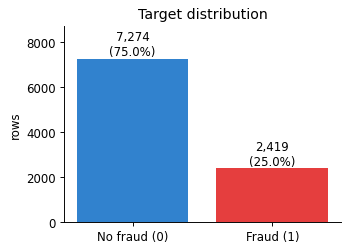

In [18]:
display(pd.DataFrame({"metric": ["rows", "columns", "continuous/count features", "binary flags",
                                 "categorical features", "missing cells", "duplicate rows"],
                      "value": [len(df), df.shape[1], len(cont), len(binary), len(cat),
                                int(df.isna().sum().sum()), int(df.duplicated().sum())]}))

vc = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4.2, 3))
bars = ax.bar(["No fraud (0)", "Fraud (1)"], vc.values, color=[C0, C1])
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v / len(y):.1%})", ha="center", va="bottom")
ax.set_ylim(0, vc.max() * 1.2); ax.set_ylabel("rows"); ax.set_title("Target distribution")
plt.show()
findings.append(f"Target is imbalanced: {vc[1] / len(y):.1%} fraud vs {vc[0] / len(y):.1%} non-fraud "
                f"(about {vc[0] / vc[1]:.1f}:1). Use stratified splits and class weights / resampling; "
                f"judge models by ROC-AUC, PR-AUC, recall and F1, not accuracy.")

### 3.2 Missing values

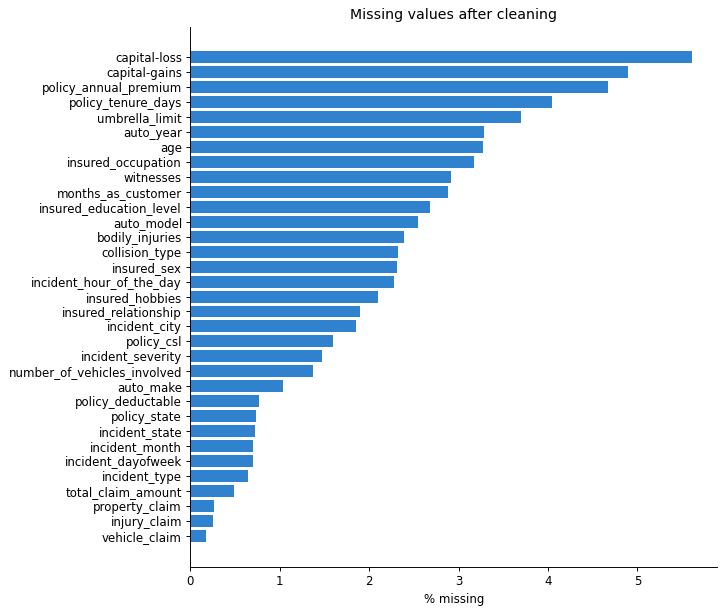

In [19]:
miss_pct = (df.isna().mean() * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
fig, ax = plt.subplots(figsize=(8, max(3, 0.25 * len(miss_pct))))
ax.barh(miss_pct.index[::-1], miss_pct.values[::-1], color=C0)
ax.set_xlabel("% missing"); ax.set_title("Missing values after cleaning")
plt.show()
findings.append("Highest missingness after cleaning: " +
                ", ".join(f"{k} ({v:.1f}%)" for k, v in miss_pct.head(3).items()) +
                ". All gaps are below 20%, so imputation (fit on train only) is used rather than dropping.")

### 3.3 Numeric features: summary, skewness, outliers

In [20]:
desc = df[cont].describe().T
desc["skew"] = df[cont].skew()
desc["missing_%"] = df[cont].isna().mean() * 100
display(desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "missing_%"]].round(2))

skewed = desc["skew"][desc["skew"].abs() > 1].sort_values(key=abs, ascending=False)
if len(skewed):
    findings.append("Strongly skewed numeric features (|skew| > 1): " +
                    ", ".join(f"{k} ({v:+.1f})" for k, v in skewed.items()) +
                    ". A Yeo-Johnson power transform is applied to these in preprocessing.")

,count,mean,std,min,25%,50%,75%,max,skew,missing_%
months_as_customer,9414.0,204.54,113.90,0.00,119.00,195.00,278.00,572.00,0.37,2.88
age,9376.0,39.03,9.24,19.00,32.00,38.00,45.00,64.00,0.46,3.27
policy_deductable,9619.0,1121.48,606.15,500.00,500.00,1000.00,2000.00,2000.00,0.52,0.76
policy_annual_premium,9240.0,1252.30,254.30,62.31,1083.01,1258.18,1418.15,2047.59,-0.22,4.67
umbrella_limit,9334.0,1073709.02,2252545.69,0.00,0.00,0.00,0.00,10000000.00,1.81,3.70
capital-gains,9219.0,26024.98,27917.65,0.00,0.00,17700.00,51700.00,102500.00,0.42,4.89
capital-loss,9149.0,-27087.19,28298.18,-112400.00,-52000.00,-24300.00,0.00,0.00,-0.39,5.61
incident_hour_of_the_day,9472.0,11.58,6.98,0.00,6.00,12.00,17.00,23.00,-0.03,2.28
number_of_vehicles_involved,9560.0,1.83,1.02,1.00,1.00,1.00,3.00,4.00,0.53,1.37
bodily_injuries,9461.0,1.00,0.81,0.00,0.00,1.00,2.00,2.00,0.01,2.39


In [21]:
# Outliers with the 1.5 x IQR rule. Impossible values were already removed in cleaning;
# what remains are plausible extremes, which we keep (scaling / power transforms tame them).
rows = []
for c in cont:
    s = df[c].dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    rows.append({"feature": c, "lower_fence": lo, "upper_fence": hi,
                 "n_outliers": n_out, "outlier_%": n_out / len(s) * 100})
outliers = pd.DataFrame(rows).sort_values("n_outliers", ascending=False).reset_index(drop=True)
display(outliers.round(2))
heavy = outliers[outliers["outlier_%"] > 2]
if len(heavy):
    findings.append("Features with more than 2% IQR-outliers: " + ", ".join(heavy["feature"]) + ".")

,feature,lower_fence,upper_fence,n_outliers,outlier_%
0,umbrella_limit,0.00,0.00,1849,19.81
1,policy_annual_premium,580.30,1920.85,99,1.07
2,property_claim,-5567.50,20652.50,67,0.69
3,vehicle_claim,-4113.75,84136.25,46,0.48
4,injury_claim,-6420.00,21660.00,28,0.29
5,total_claim_amount,-6212.50,117307.50,12,0.12
6,months_as_customer,-119.50,516.50,1,0.01
7,policy_deductable,-1750.00,4250.00,0,0.00
8,age,12.50,64.50,0,0.00
9,capital-gains,-77550.00,129250.00,0,0.00


### 3.4 Distributions by fraud class

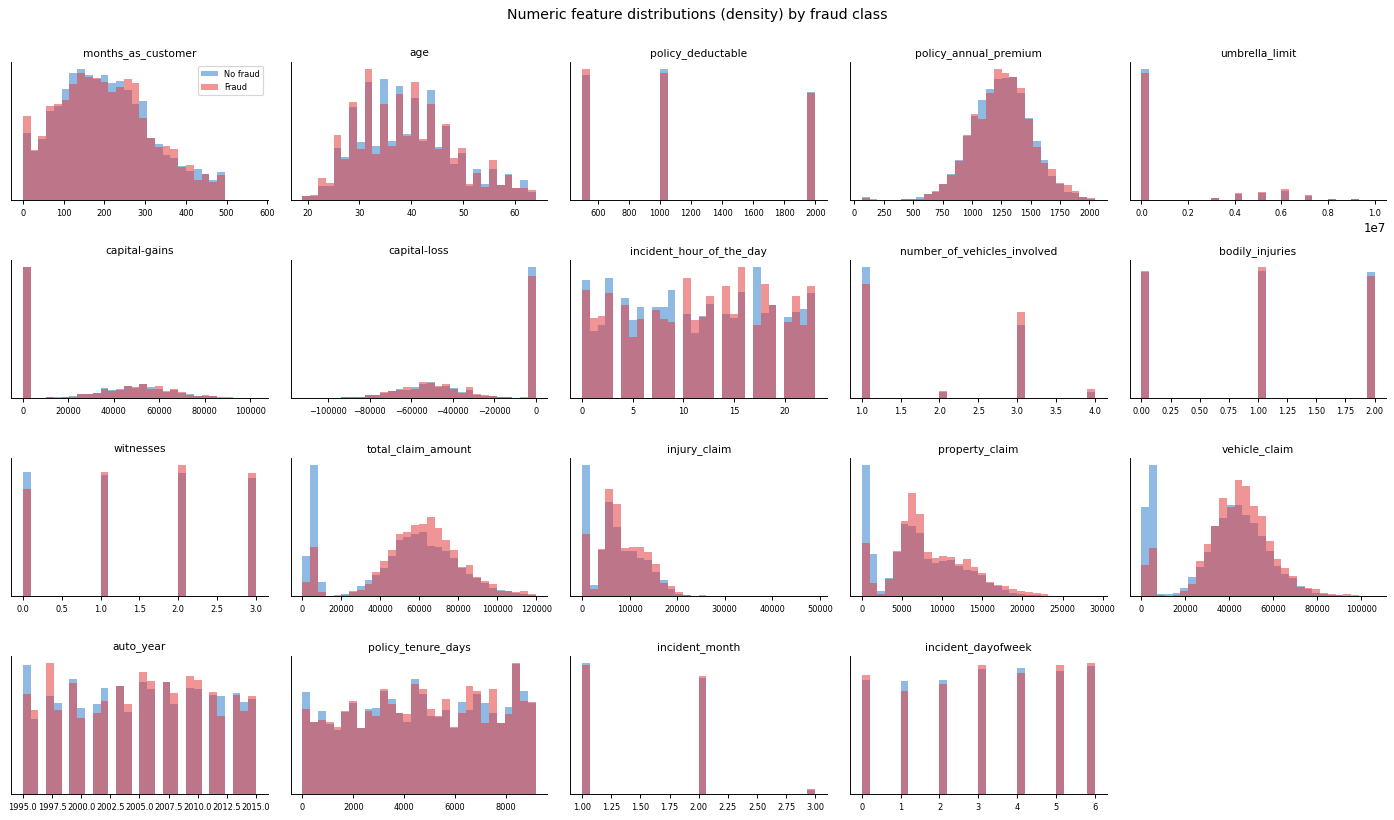

In [22]:
fig, axes = grid(len(cont), ncols=5, w=3.3, h=2.4)
for ax, c in zip(axes, cont):
    x = df[c]
    bins = np.histogram_bin_edges(x.dropna(), 30)
    ax.hist(x[y == 0].dropna(), bins=bins, density=True, alpha=.55, color=C0, label="No fraud")
    ax.hist(x[y == 1].dropna(), bins=bins, density=True, alpha=.55, color=C1, label="Fraud")
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=7); ax.set_yticks([])
axes[0].legend(fontsize=7)
fig.suptitle("Numeric feature distributions (density) by fraud class", y=1.0)
fig.tight_layout()
plt.show()

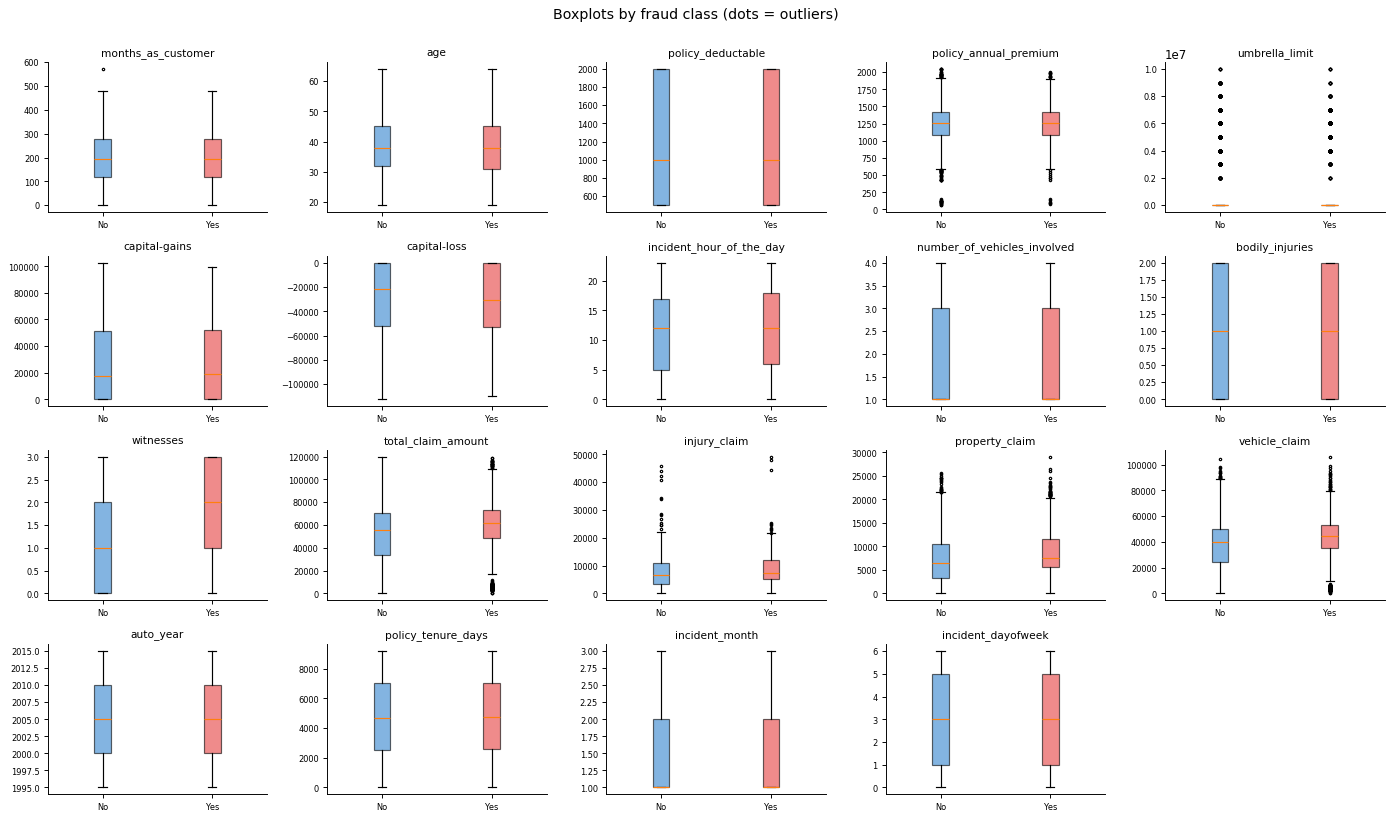

In [23]:
fig, axes = grid(len(cont), ncols=5, w=3.3, h=2.4)
for ax, c in zip(axes, cont):
    data = [df.loc[y == k, c].dropna() for k in (0, 1)]
    bp = ax.boxplot(data, patch_artist=True, flierprops={"markersize": 2})
    ax.set_xticklabels(["No", "Yes"])
    for patch, col in zip(bp["boxes"], (C0, C1)):
        patch.set_facecolor(col); patch.set_alpha(.6)
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=7)
fig.suptitle("Boxplots by fraud class (dots = outliers)", y=1.0)
fig.tight_layout()
plt.show()

### 3.5 Correlation

Strongly correlated pairs (|r| >= 0.7) - redundant for linear models; pruned automatically in section 5:


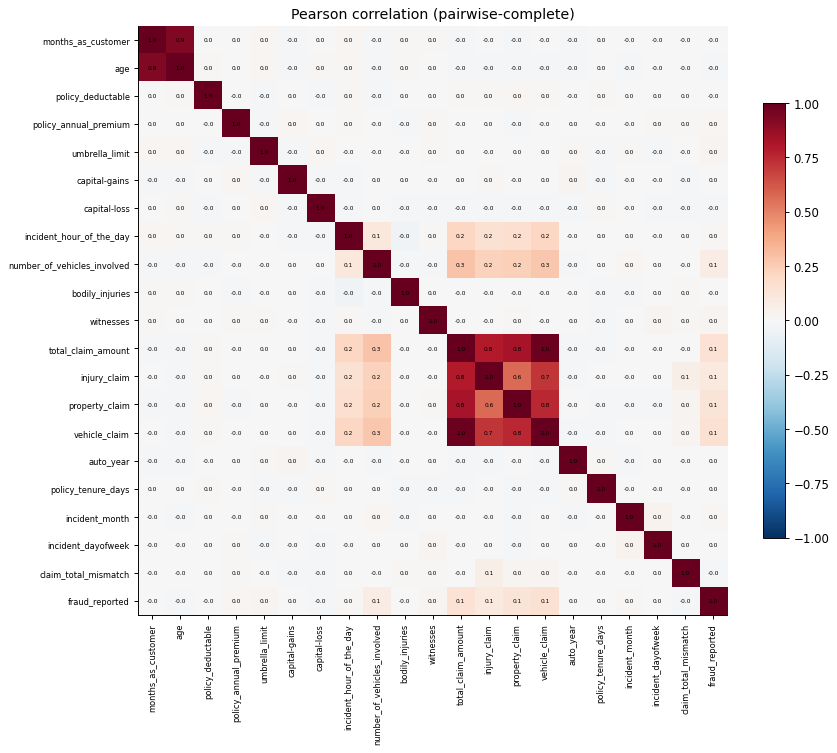

,feature_a,feature_b,r
245,total_claim_amount,vehicle_claim,0.982
1,months_as_customer,age,0.923
244,total_claim_amount,property_claim,0.820
243,total_claim_amount,injury_claim,0.796
287,property_claim,vehicle_claim,0.753
266,injury_claim,vehicle_claim,0.713


In [24]:
corr = df[cont + binary + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.1f}", ha="center", va="center", fontsize=5)
fig.colorbar(im, fraction=0.03); ax.set_title("Pearson correlation (pairwise-complete)")
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack()
         .rename("r").reset_index().rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
strong = pairs[(pairs["r"].abs() >= 0.7) & (pairs["feature_a"] != TARGET) &
               (pairs["feature_b"] != TARGET)].sort_values("r", key=abs, ascending=False)
print("Strongly correlated pairs (|r| >= 0.7) - redundant for linear models; pruned automatically in section 5:")
display(strong.round(3))
if len(strong):
    findings.append("Highly collinear pairs (|r| >= 0.7): " +
                    "; ".join(f"{a} / {b} ({r:+.2f})" for a, b, r in strong.head(4).itertuples(index=False)) + ".")

### 3.6 Categorical features

In [25]:
crows = []
for c in cat:
    vcs = df[c].value_counts(dropna=False)
    crows.append({"feature": c, "n_levels": int(df[c].nunique()), "top_level": str(vcs.index[0]),
                  "top_level_%": vcs.iloc[0] / len(df) * 100, "missing_%": df[c].isna().mean() * 100})
display(pd.DataFrame(crows).round(1))

,feature,n_levels,top_level,top_level_%,missing_%
0,policy_state,3,OH,35.0,0.7
1,policy_csl,3,250/500,35.6,1.6
2,insured_sex,2,FEMALE,53.6,2.3
3,insured_education_level,7,High School,16.2,2.7
4,insured_occupation,14,machine-op-inspct,8.7,3.2
5,insured_hobbies,20,reading,6.3,2.1
6,insured_relationship,6,own-child,18.3,1.9
7,incident_type,4,Multi-vehicle Collision,40.9,0.6
8,collision_type,4,Rear Collision,28.2,2.3
9,incident_severity,4,Minor Damage,34.8,1.5


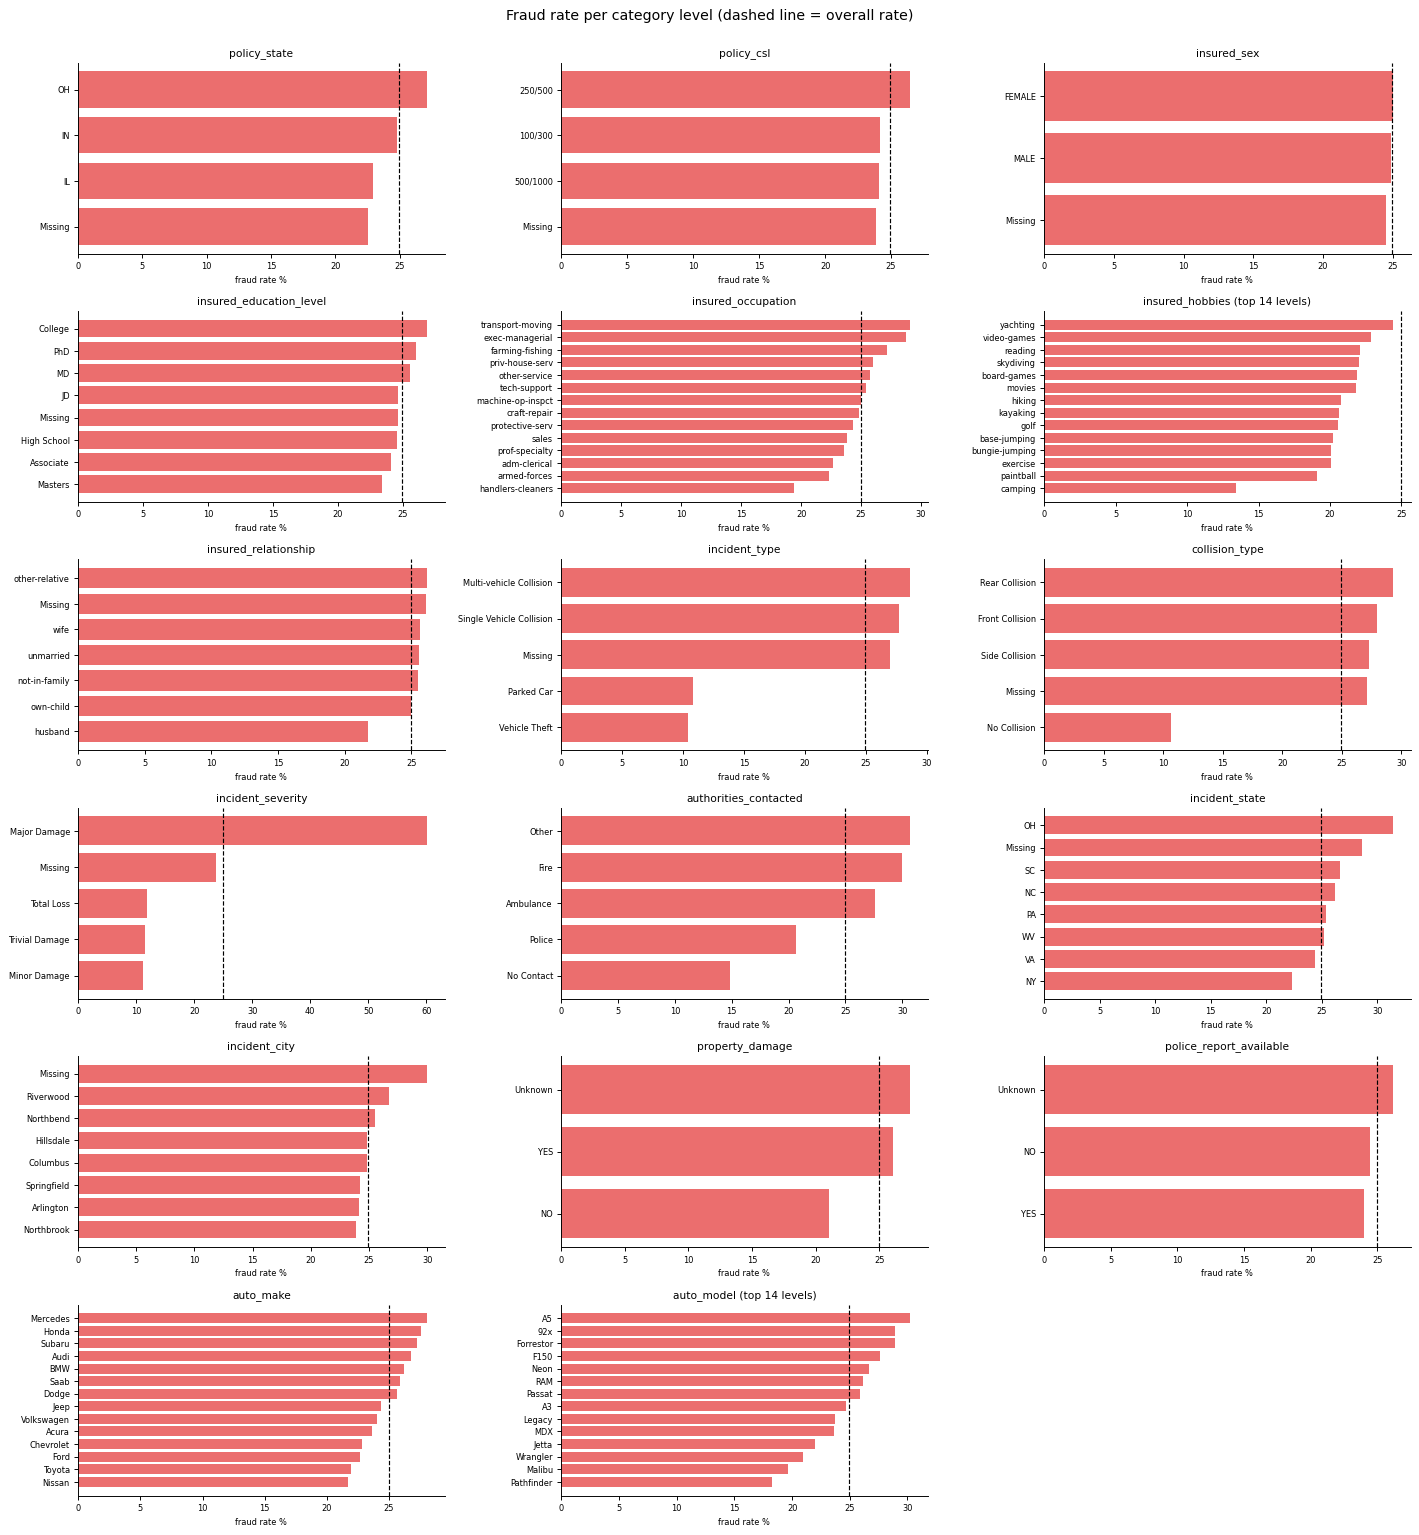

In [26]:
fig, axes = grid(len(cat), ncols=3, w=5.6, h=3.0)
overall = y.mean()
for ax, c in zip(axes, cat):
    g = df.assign(_c=df[c].fillna("Missing")).groupby("_c")[TARGET].agg(["mean", "count"])
    if len(g) > 14:
        g = g.sort_values("count", ascending=False).head(14)
    g = g.sort_values("mean")
    ax.barh(g.index.astype(str), g["mean"] * 100, color=C1, alpha=.75)
    ax.axvline(overall * 100, color="k", ls="--", lw=1)
    ax.set_title(c + (" (top 14 levels)" if df[c].nunique() > 14 else ""), fontsize=9)
    ax.tick_params(labelsize=7); ax.set_xlabel("fraud rate %", fontsize=7)
fig.suptitle("Fraud rate per category level (dashed line = overall rate)", y=1.0)
fig.tight_layout()
plt.show()

### 3.7 Which features relate to fraud?
Numeric features use the point-biserial correlation, categorical features use Cramer's V (chi-square), and both get mutual information
(which can be compared across feature types). A small p-value with a small strength means "real but weak".

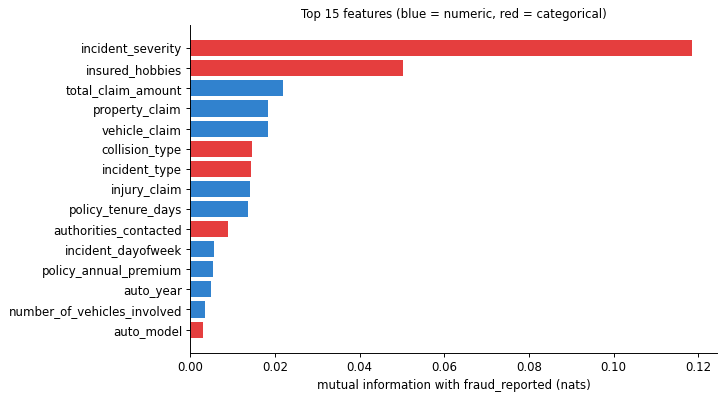

,feature,type,strength,strength_measure,p_value,mutual_info
0,incident_severity,categorical,0.5044,Cramer's V,0.0000,0.1186
1,insured_hobbies,categorical,0.3431,Cramer's V,0.0000,0.0502
2,total_claim_amount,numeric,0.1472,|point-biserial r|,0.0000,0.0219
3,property_claim,numeric,0.1260,|point-biserial r|,0.0000,0.0184
4,vehicle_claim,numeric,0.1499,|point-biserial r|,0.0000,0.0183
5,collision_type,categorical,0.1596,Cramer's V,0.0000,0.0147
6,incident_type,categorical,0.1578,Cramer's V,0.0000,0.0144
7,injury_claim,numeric,0.1004,|point-biserial r|,0.0000,0.0140
8,policy_tenure_days,numeric,0.0076,|point-biserial r|,0.4618,0.0137
9,authorities_contacted,categorical,0.1312,Cramer's V,0.0000,0.0090


In [27]:
rows = []
for c in cont + binary:
    m = df[c].notna()
    r, p = stats.pointbiserialr(y[m], df.loc[m, c])
    mi = mutual_info_classif(df.loc[m, [c]].values, y[m], random_state=SEED)[0]
    rows.append({"feature": c, "type": "numeric", "strength": abs(r),
                 "strength_measure": "|point-biserial r|", "p_value": p, "mutual_info": mi})
for c in cat:
    m = df[c].notna()
    v, p = cramers_v(pd.crosstab(df.loc[m, c], y[m]))
    mi = mutual_info_score(df.loc[m, c].astype(str), y[m])
    rows.append({"feature": c, "type": "categorical", "strength": v,
                 "strength_measure": "Cramer's V", "p_value": p, "mutual_info": mi})
assoc = pd.DataFrame(rows).sort_values("mutual_info", ascending=False).reset_index(drop=True)

top = assoc.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"], top["mutual_info"], color=[C0 if t == "numeric" else C1 for t in top["type"]])
ax.set_xlabel("mutual information with fraud_reported (nats)")
ax.set_title("Top 15 features (blue = numeric, red = categorical)", fontsize=10)
plt.show()
display(assoc.round(4))

sig = assoc[assoc["p_value"] < 0.05]
findings.append("Top features by mutual information: " + ", ".join(assoc["feature"].head(5)) +
                f". {len(sig)} of {len(assoc)} features show a statistically significant relationship with fraud (p < 0.05).")
weak = assoc[assoc["mutual_info"] < 0.0005]["feature"].tolist()
if weak:
    findings.append("Features with almost no relationship to fraud (mutual info ~ 0): " + ", ".join(weak[:10]) +
                    ". They are kept by default - drop them if you want a leaner model.")

### 3.8 Key findings

In [28]:
print("KEY FINDINGS\n" + "=" * 12)
for i, f in enumerate(findings, 1):
    print(f"{i}. {f}\n")

KEY FINDINGS
1. Target is imbalanced: 25.0% fraud vs 75.0% non-fraud (about 3.0:1). Use stratified splits and class weights / resampling; judge models by ROC-AUC, PR-AUC, recall and F1, not accuracy.

2. Highest missingness after cleaning: capital-loss (5.6%), capital-gains (4.9%), policy_annual_premium (4.7%). All gaps are below 20%, so imputation (fit on train only) is used rather than dropping.

3. Strongly skewed numeric features (|skew| > 1): umbrella_limit (+1.8). A Yeo-Johnson power transform is applied to these in preprocessing.

4. Features with more than 2% IQR-outliers: umbrella_limit.

5. Highly collinear pairs (|r| >= 0.7): total_claim_amount / vehicle_claim (+0.98); months_as_customer / age (+0.92); total_claim_amount / property_claim (+0.82); total_claim_amount / injury_claim (+0.80).

6. Top features by mutual information: incident_severity, insured_hobbies, total_claim_amount, property_claim, vehicle_claim. 20 of 37 features show a statistically significant relationshi

## 4. Feature engineering
Only **row-wise** transformations here (each row uses only its own values), so nothing can leak from test rows into training.

| New feature | Definition |
|---|---|
| `vehicle_age` | 2015 - `auto_year` |
| `net_capital` | `capital-gains` + `capital-loss` |
| `injury_ratio`, `property_ratio`, `vehicle_ratio` | each claim component / `total_claim_amount` |
| `claim_per_vehicle` | `total_claim_amount` / `number_of_vehicles_involved` |
| `claim_to_premium` | `total_claim_amount` / `policy_annual_premium` |
| `hour_sin`, `hour_cos` | cyclical encoding of the hour (23:00 is close to 00:00) |
| `incident_month`, `incident_dayofweek` | turned into categories |

In [29]:
def engineer_features(df):
    df = df.copy()
    df["vehicle_age"] = (REFERENCE_YEAR - df["auto_year"]).clip(lower=0)
    df["net_capital"] = df[["capital-gains", "capital-loss"]].sum(axis=1, min_count=1)
    tot = df["total_claim_amount"].where(df["total_claim_amount"] > 0)
    for part, name in [("injury_claim", "injury_ratio"), ("property_claim", "property_ratio"),
                       ("vehicle_claim", "vehicle_ratio")]:
        df[name] = df[part] / tot
    df["claim_per_vehicle"] = df["total_claim_amount"] / df["number_of_vehicles_involved"].where(
        df["number_of_vehicles_involved"] > 0)
    df["claim_to_premium"] = df["total_claim_amount"] / df["policy_annual_premium"].where(
        df["policy_annual_premium"] > 0)
    ang = 2 * np.pi * df["incident_hour_of_the_day"] / 24
    df["hour_sin"], df["hour_cos"] = np.sin(ang), np.cos(ang)
    df = df.drop(columns=["auto_year", "incident_hour_of_the_day"])
    df = df.replace([np.inf, -np.inf], np.nan)
    # month / weekday are categories
    for c in CAT_AS_NUMERIC:
        df[c] = df[c].map(lambda v: np.nan if pd.isna(v) else str(int(v)))
    # sklearn-friendly dtypes: categoricals as object with np.nan
    for c in df.columns:
        if c != TARGET and not pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].astype(object).where(df[c].notna(), np.nan)
    return df

df_fe = engineer_features(df)
new_feats = ["vehicle_age", "net_capital", "injury_ratio", "property_ratio", "vehicle_ratio",
             "claim_per_vehicle", "claim_to_premium", "hour_sin", "hour_cos"]
print(f"Shape after feature engineering: {df_fe.shape}")
display(df_fe[new_feats].describe().T.round(3))

Shape after feature engineering: (9693, 45)


,count,mean,std,min,25%,50%,75%,max
vehicle_age,9375.0,10.021,6.015,0.00,5.000,10.000,15.000,20.000
net_capital,9668.0,-816.755,39392.804,-112400.00,-31300.000,0.000,28100.000,101900.000
injury_ratio,9627.0,0.140,0.054,0.00,0.100,0.125,0.182,0.910
property_ratio,9626.0,0.138,0.048,0.00,0.100,0.125,0.182,0.333
vehicle_ratio,9630.0,0.722,0.063,0.08,0.692,0.727,0.777,1.000
claim_per_vehicle,9513.0,35499.242,26943.509,0.00,14680.000,25283.333,57500.000,119610.000
claim_to_premium,9194.0,45.065,39.861,0.00,29.751,45.180,58.888,1032.009
hour_sin,9472.0,-0.019,0.711,-1.00,-0.707,0.000,0.707,1.000
hour_cos,9472.0,0.010,0.703,-1.00,-0.707,-0.000,0.707,1.000


## 5. Preprocessing (everything is fitted on the TRAIN set only)

### 5.1 Stratified train / test split
We split **first**. Every imputer, scaler, encoder and pruning decision below learns only from training rows, then is applied to the test rows - this prevents data leakage.

In [30]:
X = df_fe.drop(columns=[TARGET])
y_all = df_fe[TARGET].astype(int)
Xtr, Xte, ytr, yte = train_test_split(X, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=SEED)
print(f"train: {Xtr.shape}   test: {Xte.shape}")
print(f"fraud rate  train: {ytr.mean():.3f}   test: {yte.mean():.3f}   (stratified -> equal)")

train: (7754, 44)   test: (1939, 44)
fraud rate  train: 0.250   test: 0.250   (stratified -> equal)


### 5.2 Group the columns by how they will be treated

In [31]:
cat_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
ord_cols = [c for c in ORDINAL_ORDER if c in cat_cols]          # ordered categories
nom_cols = [c for c in cat_cols if c not in ord_cols]           # unordered categories
num_all = [c for c in X.columns if c not in cat_cols]
bin_cols = [c for c in num_all if set(Xtr[c].dropna().unique()) <= {0, 1, 0.0, 1.0}]
num_cols = [c for c in num_all if c not in bin_cols]

groups = pd.Series({"numeric": len(num_cols), "binary flags": len(bin_cols),
                    "ordinal categorical": len(ord_cols), "nominal categorical": len(nom_cols)})
display(groups.rename("n_columns").to_frame())

,n_columns
numeric,24
binary flags,1
ordinal categorical,3
nominal categorical,16


### 5.3 Collinearity pruning
When two numeric features are almost the same (|r| above the threshold), keep the one with the stronger relationship to the target and drop the other.
Decided on the **training rows only**.

In [32]:
def prune_correlated(Xtr, ytr, cols, threshold):
    corr = Xtr[cols].corr().abs()
    tcorr = Xtr[cols].apply(lambda s: s.corr(ytr)).abs().fillna(0)
    pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack()
             .sort_values(ascending=False))
    drop, log_rows = set(), []
    for (a, b), r in pairs.items():
        if r < threshold:
            break
        if a in drop or b in drop:
            continue
        loser = a if tcorr[a] < tcorr[b] else b
        drop.add(loser)
        log_rows.append({"feature_a": a, "feature_b": b, "|r|": r, "dropped": loser,
                         "reason": "weaker relationship with target"})
    return sorted(drop), pd.DataFrame(log_rows)

dropped, drop_log = prune_correlated(Xtr, ytr, num_cols, CORR_THRESHOLD)
num_cols = [c for c in num_cols if c not in dropped]
Xtr, Xte = Xtr.drop(columns=dropped), Xte.drop(columns=dropped)
print(f"Dropped {len(dropped)} collinear feature(s): {dropped}")
display(drop_log.round(3))

Dropped 2 collinear feature(s): ['months_as_customer', 'total_claim_amount']


,feature_a,feature_b,|r|,dropped,reason
0,total_claim_amount,vehicle_claim,0.982,total_claim_amount,weaker relationship with target
1,months_as_customer,age,0.922,months_as_customer,weaker relationship with target


### 5.4 Skewness -> which features get a power transform

In [33]:
skew = Xtr[num_cols].skew()
skew_cols = [c for c in num_cols if abs(skew[c]) > 1]
plain_cols = [c for c in num_cols if c not in skew_cols]
print("Skewed (|skew| > 1) -> Yeo-Johnson:", {c: round(float(skew[c]), 2) for c in skew_cols})
print("Other numeric -> StandardScaler:", plain_cols)

Skewed (|skew| > 1) -> Yeo-Johnson: {'umbrella_limit': 1.8, 'claim_to_premium': 10.81}
Other numeric -> StandardScaler: ['age', 'policy_deductable', 'policy_annual_premium', 'capital-gains', 'capital-loss', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim', 'policy_tenure_days', 'vehicle_age', 'net_capital', 'injury_ratio', 'property_ratio', 'vehicle_ratio', 'claim_per_vehicle', 'hour_sin', 'hour_cos']


### 5.5 Build the preprocessing pipeline

| Group | Steps |
|---|---|
| Skewed numeric | median imputation -> Yeo-Johnson power transform (also standardises) |
| Other numeric | median imputation -> standard scaling |
| Ordinal categorical | most-frequent imputation -> ordered integer encoding -> scaling |
| Nominal categorical | most-frequent imputation -> one-hot (binary columns become a single 0/1 column) |
| Binary flags | passed through |

Ordering assumptions (edit `ORDINAL_ORDER` in section 2.1 to change): education High School < Associate < College < Masters < JD < MD < PhD
(the last three are an arbitrary tie-break), severity Trivial < Minor < Major < Total Loss, CSL 100/300 < 250/500 < 500/1000.

In [34]:
pre = ColumnTransformer([
    ("skewed_numeric", Pipeline([("impute", SimpleImputer(strategy="median")),
                                 ("power", PowerTransformer(method="yeo-johnson"))]), skew_cols),
    ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), plain_cols),
    ("ordinal", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", OrdinalEncoder(categories=[ORDINAL_ORDER[c] for c in ord_cols])),
                          ("scale", StandardScaler())]), ord_cols),
    ("nominal", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                                   drop="if_binary"))]), nom_cols),
    ("binary", "passthrough", bin_cols),
], verbose_feature_names_out=False)
pre.set_output(transform="pandas")
pre

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed_numeric', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

### 5.6 Fit on train, transform train and test

In [35]:
Xtr_p = pre.fit_transform(Xtr)      # learns medians, scalers, categories from TRAIN only
Xte_p = pre.transform(Xte)          # applies them to TEST

# sanity checks
assert not Xtr_p.isna().any().any() and not Xte_p.isna().any().any(), "NaN left after preprocessing"
assert np.isfinite(Xtr_p.values).all() and np.isfinite(Xte_p.values).all(), "inf left after preprocessing"
assert list(Xtr_p.columns) == list(Xte_p.columns)
print(f"X_train: {Xtr_p.shape} | X_test: {Xte_p.shape} | NaN: 0 | columns identical")

cont_out = [c for c in Xtr_p.columns if Xtr_p[c].nunique() > 2]
print(f"\nContinuous columns, TRAIN -> mean range [{Xtr_p[cont_out].mean().min():.2f}, {Xtr_p[cont_out].mean().max():.2f}], "
      f"std range [{Xtr_p[cont_out].std().min():.2f}, {Xtr_p[cont_out].std().max():.2f}]")
print(f"Continuous columns, TEST  -> mean range [{Xte_p[cont_out].mean().min():.2f}, {Xte_p[cont_out].mean().max():.2f}] (close to 0 = no leakage, no drift)")
display(Xtr_p.head())

X_train: (7754, 166) | X_test: (1939, 166) | NaN: 0 | columns identical

Continuous columns, TRAIN -> mean range [-0.00, 0.00], std range [1.00, 1.00]
Continuous columns, TEST  -> mean range [-0.06, 0.05] (close to 0 = no leakage, no drift)


,umbrella_limit,claim_to_premium,age,policy_deductable,policy_annual_premium,capital-gains,capital-loss,number_of_vehicles_involved,bodily_injuries,witnesses,injury_claim,property_claim,vehicle_claim,policy_tenure_days,vehicle_age,net_capital,injury_ratio,property_ratio,vehicle_ratio,claim_per_vehicle,hour_sin,hour_cos,insured_education_level,incident_severity,policy_csl,policy_state_IL,policy_state_IN,policy_state_OH,insured_sex_MALE,insured_occupation_adm-clerical,...,auto_model_Jetta,auto_model_Legacy,auto_model_M5,auto_model_MDX,auto_model_ML350,auto_model_Malibu,auto_model_Maxima,auto_model_Neon,auto_model_Passat,auto_model_Pathfinder,auto_model_RAM,auto_model_RSX,auto_model_Silverado,auto_model_TL,auto_model_Tahoe,auto_model_Ultima,auto_model_Wrangler,auto_model_X5,auto_model_X6,incident_month_1,incident_month_2,incident_month_3,incident_dayofweek_0,incident_dayofweek_1,incident_dayofweek_2,incident_dayofweek_3,incident_dayofweek_4,incident_dayofweek_5,incident_dayofweek_6,claim_total_mismatch
3692,-0.488121,0.380021,1.210157,-1.024224,0.371904,0.366160,0.981009,-0.800987,1.251798,-1.395830,-0.108428,-0.094900,0.864682,-0.004809,-0.169684,0.925494,-0.755487,-0.791064,1.257042,1.254066,1.019782,1.011703,1.551999,-0.732235,0.072665,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
967,-0.488121,0.244920,0.003099,1.470332,0.579458,0.902851,0.260909,1.170399,-1.238629,0.429803,0.661273,0.704497,0.277497,1.380618,1.351196,0.793160,0.512579,0.596609,-0.896088,-0.505967,-1.208898,-0.731976,0.080825,-0.732235,1.336001,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2192,-0.488121,-1.975955,0.442029,-0.192706,-0.881328,-0.931455,0.089977,-0.800987,1.251798,0.429803,-1.394510,-1.430601,-1.800504,0.181218,1.182209,0.027145,-0.561161,-0.578408,0.927083,-1.223516,1.386454,0.364146,0.571217,-0.732235,0.072665,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
2601,-0.488121,-0.623503,-0.655296,1.470332,-0.045853,-0.931455,0.981009,1.170399,0.006584,-0.483013,-0.845002,-0.859893,-0.810477,0.104122,-0.676644,0.027145,-0.543152,-0.558701,0.896505,-0.968629,0.384686,-1.405011,-1.390348,1.334280,1.336001,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
5535,-0.488121,0.221068,-1.533156,1.470332,1.296399,2.149003,0.981009,-0.800987,0.006584,-1.395830,0.111765,-0.117162,0.171764,1.478043,-1.690564,2.159770,-0.542738,-0.272812,0.081572,1.375590,1.019782,1.011703,1.061608,1.334280,-1.190670,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0


In [36]:
recipe = pd.DataFrame([
    ["Skewed numeric", "median impute -> Yeo-Johnson", len(skew_cols), ", ".join(skew_cols)],
    ["Other numeric", "median impute -> StandardScaler", len(plain_cols), ", ".join(plain_cols)],
    ["Ordinal categorical", "mode impute -> ordered encode -> scale", len(ord_cols), ", ".join(ord_cols)],
    ["Nominal categorical", "mode impute -> one-hot", len(nom_cols), ", ".join(nom_cols)],
    ["Binary flags", "passthrough", len(bin_cols), ", ".join(bin_cols)],
], columns=["group", "steps", "n_input_features", "features"])
pd.set_option("display.max_colwidth", 120)
display(recipe)
print(f"\n{len(Xtr.columns)} input features -> {Xtr_p.shape[1]} model columns after encoding")


42 input features -> 166 model columns after encoding


,group,steps,n_input_features,features
0,Skewed numeric,median impute -> Yeo-Johnson,2,"umbrella_limit, claim_to_premium"
1,Other numeric,median impute -> StandardScaler,20,"age, policy_deductable, policy_annual_premium, capital-gains, capital-loss, number_of_vehicles_involved, bodily_inju..."
2,Ordinal categorical,mode impute -> ordered encode -> scale,3,"insured_education_level, incident_severity, policy_csl"
3,Nominal categorical,mode impute -> one-hot,16,"policy_state, insured_sex, insured_occupation, insured_hobbies, insured_relationship, incident_type, collision_type,..."
4,Binary flags,passthrough,1,claim_total_mismatch


### 5.7 Effect of the power transform

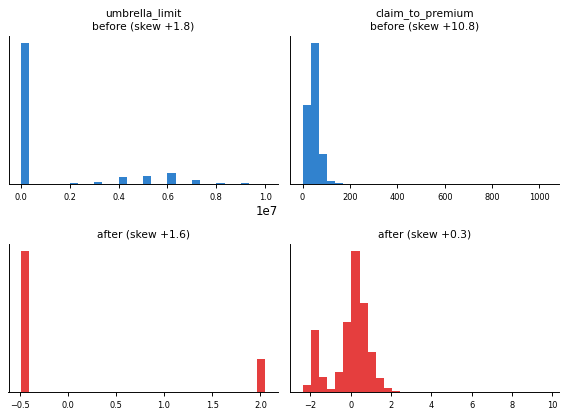

In [37]:
show = skew_cols[:6]
fig, axes = plt.subplots(2, len(show), figsize=(3.4 * len(show), 5), squeeze=False)
for j, c in enumerate(show):
    axes[0, j].hist(Xtr[c].dropna(), bins=30, color=C0)
    axes[0, j].set_title(f"{c}\nbefore (skew {skew[c]:+.1f})", fontsize=9)
    axes[1, j].hist(Xtr_p[c], bins=30, color=C1)
    axes[1, j].set_title(f"after (skew {Xtr_p[c].skew():+.1f})", fontsize=9)
    for a in axes[:, j]:
        a.tick_params(labelsize=7); a.set_yticks([])
fig.tight_layout()
plt.show()

### 5.8 Class imbalance
About 25% of rows are fraud. Two options, both computed on the **training set only** (the test set is never resampled):

1. **Class weights** - pass `class_weight=...` to your model.
2. **A balanced copy of the training set** - random oversampling of the minority class (or SMOTE if `BALANCE_METHOD = "smote"` and `imbalanced-learn` is installed).

In [38]:
def balance_train(Xtr, ytr, method, seed):
    if method == "none":
        return Xtr, ytr, "none"
    if method == "smote":
        try:
            from imblearn.over_sampling import SMOTE
            Xb, yb = SMOTE(random_state=seed).fit_resample(Xtr, ytr)
            return Xb, yb, "SMOTE"
        except ImportError:
            print("imbalanced-learn not installed -> falling back to random oversampling "
                "(pip install imbalanced-learn for SMOTE)")
    Xtr, ytr = Xtr.reset_index(drop=True), ytr.reset_index(drop=True)
    minority = ytr.value_counts().idxmin()
    maj_n = ytr.value_counts().max()
    Xup, yup = resample(Xtr[ytr == minority], ytr[ytr == minority], replace=True,
                        n_samples=maj_n, random_state=seed)
    Xall = pd.concat([Xtr[ytr != minority], Xup])
    yall = pd.concat([ytr[ytr != minority], yup])
    perm = np.random.RandomState(seed).permutation(len(Xall))   # shuffle X and y together
    return (Xall.iloc[perm].reset_index(drop=True), yall.iloc[perm].reset_index(drop=True),
            "random oversampling")

cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=ytr)
class_weights = {0: float(cw[0]), 1: float(cw[1])}
print("Class weights for training:", {k: round(v, 3) for k, v in class_weights.items()})

if BALANCE_METHOD != "none":
    Xb, yb, balance_used = balance_train(Xtr_p, ytr.reset_index(drop=True), BALANCE_METHOD, SEED)
    print(f"Balanced training copy ({balance_used}): {len(Xb):,} rows, fraud rate {yb.mean():.1%} "
          f"(original train: {len(Xtr_p):,} rows, {ytr.mean():.1%})")
else:
    Xb = yb = None
    balance_used = "none"
    print("BALANCE_METHOD = 'none' -> no balanced copy created")

Class weights for training: {0: 0.666, 1: 2.004}
Balanced training copy (random oversampling): 11,638 rows, fraud rate 50.0% (original train: 7,754 rows, 25.0%)


## 6. Save the model-ready files & verify

In [39]:
proc = OUTDIR / "processed"
Xtr_p.to_csv(proc / "X_train.csv", index=False)
Xte_p.to_csv(proc / "X_test.csv", index=False)
ytr.to_csv(proc / "y_train.csv", index=False, header=True)
yte.to_csv(proc / "y_test.csv", index=False, header=True)
if Xb is not None:
    Xb.to_csv(proc / "X_train_balanced.csv", index=False)
    yb.to_csv(proc / "y_train_balanced.csv", index=False, header=True)
joblib.dump(pre, proc / "preprocessor.joblib")
(proc / "feature_names.txt").write_text("\n".join(Xtr_p.columns))

summary = {
    "train_shape": list(Xtr_p.shape), "test_shape": list(Xte_p.shape),
    "n_features_after_encoding": int(Xtr_p.shape[1]),
    "dropped_collinear": dropped, "power_transformed": skew_cols,
    "class_weights": class_weights, "balancing": balance_used,
    "seed": SEED, "test_size": TEST_SIZE, "corr_threshold": CORR_THRESHOLD,
}
(proc / "pipeline_summary.json").write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "train_shape": [
    7754,
    166
  ],
  "test_shape": [
    1939,
    166
  ],
  "n_features_after_encoding": 166,
  "dropped_collinear": [
    "months_as_customer",
    "total_claim_amount"
  ],
  "power_transformed": [
    "umbrella_limit",
    "claim_to_premium"
  ],
  "class_weights": {
    "0": 0.6662656813885547,
    "1": 2.0036175710594315
  },
  "balancing": "random oversampling",
  "seed": 42,
  "test_size": 0.2,
  "corr_threshold": 0.9
}


In [40]:
# Round-trip check: does the SAVED preprocessor reproduce the test matrix exactly?
pre_loaded = joblib.load(proc / "preprocessor.joblib")
same = np.allclose(pre_loaded.transform(Xte).values, Xte_p.values)
print("Saved preprocessor reproduces X_test exactly:", same)
assert same

print("\nFiles written:")
for p in sorted(OUTDIR.rglob("*")):
    if p.is_file():
        print(f"  {str(p):<48} {p.stat().st_size / 1024:>9,.1f} KB")

Saved preprocessor reproduces X_test exactly: True

Files written:
  output/insurance_claims_cleaned.csv                2,270.2 KB
  output/processed/X_test.csv                        1,996.7 KB
  output/processed/X_train.csv                       7,976.2 KB
  output/processed/X_train_balanced.csv             11,968.4 KB
  output/processed/feature_names.txt                     3.5 KB
  output/processed/pipeline_summary.json                 0.4 KB
  output/processed/preprocessor.joblib                  16.2 KB
  output/processed/y_test.csv                            3.8 KB
  output/processed/y_train.csv                          15.2 KB
  output/processed/y_train_balanced.csv                 22.7 KB


## 7. Summary & how to reuse

**You now have** `X_train`, `X_test`, `y_train`, `y_test` (plus a balanced training copy) in `output/processed/`, ready for any scikit-learn model, e.g.

```python
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
Xtr = pd.read_csv("output/processed/X_train.csv"); ytr = pd.read_csv("output/processed/y_train.csv").squeeze()
Xte = pd.read_csv("output/processed/X_test.csv");  yte = pd.read_csv("output/processed/y_test.csv").squeeze()
model = RandomForestClassifier(class_weight="balanced", random_state=42).fit(Xtr, ytr)
```

**To process new raw data:** point `INPUT_PATH` at the new file, run sections 2 and 4 to clean it and engineer features, then
`joblib.load("output/processed/preprocessor.joblib").transform(new_X)` (drop the target column first). Do **not** re-fit on new data.

**Things you may want to tweak:** `NUMERIC_RANGES` (validity limits), `ORDINAL_ORDER` (category order), `CORR_THRESHOLD`, `BALANCE_METHOD`, `TEST_SIZE`.